In [3]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
x = data.data
y = data.target


class logisticRegression:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs

    def sigmoid(self, z):
        return 1/(1+np.exp(-z))

    def loss(self, y, y_pred):
        eps=1e-9
        return -np.mean(
            y*np.log(y_pred + eps) + 
            (1-y)*np.log((1-y_pred)+eps)
        )

    def fit(self, X_train, y_train, X_test, y_test):
        n_samples, n_features = X_train.shape

        self.W = np.zeros(n_features)

        self.train_losses = []
        self.test_losses = []
        
        # Just for additional info
        self.train_accs = []

        for epoch in range(self.epochs):
            y_pred = self.sigmoid(np.dot(X_train, self.W))
                                  
            train_loss = self.loss(y_train, y_pred)
            self.train_losses.append(train_loss)

            # Optional added for additional information done by chatgpt not me :)
            train_pred = (y_pred >= 0.5).astype(int)
            train_acc = np.mean(train_pred == y_train)
            self.train_accs.append(train_acc)


            dw = (1/n_samples)*np.dot(X_train.T, (y_pred - y_train))

            self.W -= self.lr*dw

            test_pred = self.sigmoid(np.dot(X_test, self.W))
            self.test_losses.append(self.loss(y_test, test_pred))

            # Optional just added for some additional information
            if epoch % 100 == 0:
                print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")

    def predict_prob(self, X):
        return self.sigmoid(np.dot(X, self.W))

    def predict(self, X):
        return (self.predict_prob(X) >= 0.5).astype(int)


def add_bias(X):
    ones = np.ones((X.shape[0], 1))
    return np.hstack((ones, X))

X = add_bias(x)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train[:,1:] = scaler.fit_transform(X_train[:,1:])
X_test[:,1:] = scaler.transform(X_test[:,1:])

model = logisticRegression(lr=0.01, epochs=1000)
model.fit(X_train, y_train, X_test, y_test)


y_pred = model.predict(X_test)

TP = np.sum((y_test == 1) & (y_pred == 1))
TN = np.sum((y_test == 0) & (y_pred == 0))
FP = np.sum((y_test == 0) & (y_pred == 1))
FN = np.sum((y_test == 1) & (y_pred == 0))



accuracy = (TP + TN)/(TP + TN + FP + FN)
recall = TP/(TP + FN)
FPR = FP/(TN + FP)
precision = TP/(TP + FP)
F_1_score = 2*precision*recall/(precision + recall)
print("\nResult of the confusion matrix are as follows: \n")
print(f"Accuracy: {accuracy}\n Recall: {recall}\n FPR: {FPR}\n Precision: {precision}\n F1 score: {F_1_score}")
from sklearn.metrics import classification_report,accuracy_score
print(classification_report(y_test,y_pred))

Epoch 0 | Train Loss: 0.6931 | Train Acc: 0.6286
Epoch 100 | Train Loss: 0.2543 | Train Acc: 0.9516
Epoch 200 | Train Loss: 0.1917 | Train Acc: 0.9648
Epoch 300 | Train Loss: 0.1633 | Train Acc: 0.9670
Epoch 400 | Train Loss: 0.1465 | Train Acc: 0.9670
Epoch 500 | Train Loss: 0.1350 | Train Acc: 0.9692
Epoch 600 | Train Loss: 0.1267 | Train Acc: 0.9736
Epoch 700 | Train Loss: 0.1202 | Train Acc: 0.9802
Epoch 800 | Train Loss: 0.1150 | Train Acc: 0.9824
Epoch 900 | Train Loss: 0.1107 | Train Acc: 0.9824

Result of the confusion matrix are as follows: 

Accuracy: 0.9824561403508771
 Recall: 0.9859154929577465
 FPR: 0.023255813953488372
 Precision: 0.9859154929577465
 F1 score: 0.9859154929577465
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98  

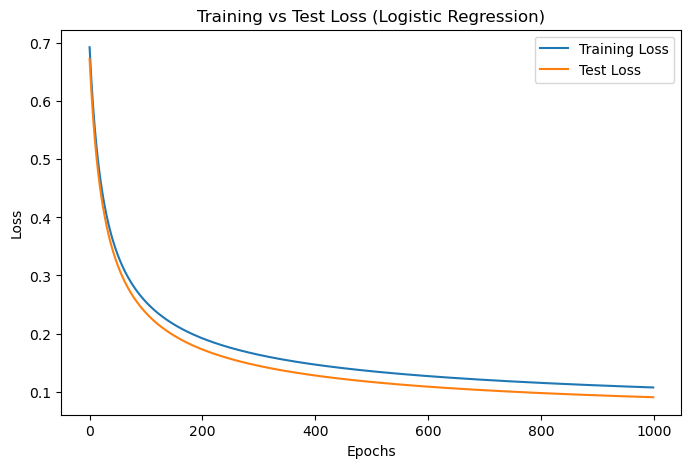

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(model.train_losses, label="Training Loss")
plt.plot(model.test_losses, label="Test Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Test Loss (Logistic Regression)")
plt.legend()
plt.show()